In [1]:
from pathlib import Path
import subprocess

REPO_URL = "https://github.com/seoultechpse/fenicsx-colab.git"
ROOT = Path("/content")
REPO_DIR = ROOT / "fenicsx-colab"

subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

USE_COMPLEX = False  # <--- Set True ONLY if you need complex PETSc
USE_CLEAN = False    # <--- Set True to remove existing environment

opts_str = " ".join(
  [o for c, o in [(USE_COMPLEX, "--complex"), (USE_CLEAN, "--clean")] if c]
)

get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_fenicsx.py'} {opts_str}")

🔧 FEniCSx Setup Configuration
PETSc type      : real
Clean install   : False

⚠️  Google Drive not mounted — using local cache (/content)

🔧 Installing FEniCSx environment...

🔍 Verifying PETSc type...
✅ Installed: Real PETSc (float64)

✨ Loading FEniCSx Jupyter magic... %%fenicsx registered

✅ FEniCSx setup complete!

Next steps:
  1. Run %%fenicsx --info to verify installation
  2. Use %%fenicsx in cells to run FEniCSx code
  3. Use -np N for parallel execution (e.g., %%fenicsx -np 4)

📌 Note: Real PETSc is installed
   - Recommended for most FEM problems
   - For complex problems, reinstall with --complex


---

# Mesh Generation in FEniCSx

This notebook demonstrates mesh creation from arrays in FEniCSx.

**Topics:**
- Creating meshes from node arrays
- Coordinate elements (P1, P2)
- Higher-order curved meshes
- Reference-to-physical mapping
- Visualization

In [3]:
%%fenicsx

# Complete example in a single cell

# ============================================================================
# SETUP AND IMPORTS
# ============================================================================
from mpi4py import MPI
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from mpl_toolkits.mplot3d import Axes3D

import basix
import basix.ufl
import dolfinx
import dolfinx.mesh
import dolfinx.plot
import ufl

print(f"DOLFINx version: {dolfinx.__version__}")
print(f"Basix version: {basix.__version__}")
print("="*70)

# ============================================================================
# 1. CREATE A SIMPLE LINEAR MESH (P1)
# ============================================================================
print("\n1. Creating a simple 2-triangle mesh (P1)...")

# Define 4 nodes in 2D
nodes = np.array([
    [1.0, 0.0],  # Node 0
    [2.0, 0.0],  # Node 1
    [3.0, 2.0],  # Node 2
    [1.0, 3.0]   # Node 3
], dtype=np.float64)

print(f"  Nodes defined: {nodes.shape[0]} nodes in {nodes.shape[1]}D")
print(f"  Coordinates:")
for i, node in enumerate(nodes):
    print(f"    Node {i}: ({node[0]:.1f}, {node[1]:.1f})")

# Define connectivity (which nodes form each triangle)
connectivity = np.array([
    [0, 1, 2],  # Triangle 1: nodes 0-1-2
    [0, 2, 3]   # Triangle 2: nodes 0-2-3
], dtype=np.int64)

print(f"  Connectivity: {connectivity.shape[0]} triangles")
print(f"    Triangle 0: nodes {connectivity[0]}")
print(f"    Triangle 1: nodes {connectivity[1]}")

# Define coordinate element (P1 Lagrange)
c_el = ufl.Mesh(
    basix.ufl.element(
        "Lagrange",              # Element family
        "triangle",              # Cell type
        1,                       # Polynomial degree (P1)
        shape=(nodes.shape[1],)  # Geometric dimension
    )
)

print(f"  Coordinate element: P1 Lagrange triangle")
print(f"    - 3 DOFs per triangle")
print(f"    - Straight edges (affine mapping)")

# Create the mesh
mesh_p1 = dolfinx.mesh.create_mesh(
    MPI.COMM_SELF,
    cells=connectivity,
    x=nodes,
    e=c_el
)

print(f"  ✓ Mesh created successfully")
print(f"    - Cells: {mesh_p1.topology.index_map(2).size_local}")
print(f"    - Vertices: {mesh_p1.topology.index_map(0).size_local}")

# ============================================================================
# 2. VISUALIZE LINEAR MESH
# ============================================================================
print("\n2. Visualizing P1 mesh...")

fig, ax = plt.subplots(figsize=(8, 8))

# Plot triangles
for cell_idx in range(connectivity.shape[0]):
    triangle_nodes = connectivity[cell_idx]
    triangle_coords = nodes[triangle_nodes]

    # Close the triangle
    triangle_coords_closed = np.vstack([triangle_coords, triangle_coords[0]])

    # Plot triangle
    ax.fill(triangle_coords[:, 0], triangle_coords[:, 1],
            alpha=0.3, edgecolor='black', linewidth=2,
            facecolor='lightblue' if cell_idx == 0 else 'lightcoral')

    # Add cell number
    centroid = triangle_coords.mean(axis=0)
    ax.text(centroid[0], centroid[1], f'Cell {cell_idx}',
            ha='center', va='center', fontsize=12, fontweight='bold')

# Plot nodes
ax.scatter(nodes[:, 0], nodes[:, 1], s=200, c='red',
           edgecolors='black', linewidths=2, zorder=5)

# Label nodes
for i, (x, y) in enumerate(nodes):
    ax.annotate(f'  {i}', (x, y), fontsize=14, fontweight='bold')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Linear Mesh (P1) - 2 Triangles', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.legend(['Triangle 0', 'Triangle 1'], loc='upper right')

plt.tight_layout()
plt.savefig('mesh_p1.png', dpi=150, bbox_inches='tight')
print("  ✓ Saved: mesh_p1.png")
plt.close()

# ============================================================================
# 3. CREATE HIGHER-ORDER MESH (P2)
# ============================================================================
print("\n3. Creating a higher-order curved mesh (P2)...")

# For P2 triangle: 6 DOFs
# l_0, l_1, l_2: vertices
# l_3, l_4, l_5: edge midpoints
nodes_p2 = np.array([
    [1.0, 0.0],    # l_0: vertex 0
    [2.0, 0.0],    # l_1: vertex 1
    [3.0, 2.0],    # l_2: vertex 2
    [2.5, 1.0],    # l_3: midpoint of edge 1-2
    [2.0, 1.0],    # l_4: midpoint of edge 0-2
    [1.5, -0.3]    # l_5: midpoint of edge 0-1 (CURVED!)
], dtype=np.float64)

connectivity_p2 = np.array([[0, 1, 2, 3, 4, 5]], dtype=np.int64)

print(f"  Nodes for P2 triangle: 6 nodes")
print(f"    - 3 vertices: nodes 0, 1, 2")
print(f"    - 3 edge midpoints: nodes 3, 4, 5")
print(f"  Note: Node 5 at y=-0.3 creates curvature!")

# P2 coordinate element
c_el_p2 = ufl.Mesh(
    basix.ufl.element(
        "Lagrange",
        "triangle",
        2,                       # Polynomial degree (P2)
        shape=(nodes_p2.shape[1],)
    )
)

print(f"  Coordinate element: P2 Lagrange triangle")
print(f"    - 6 DOFs per triangle")
print(f"    - Curved edges (quadratic mapping)")

# Create P2 mesh
mesh_p2 = dolfinx.mesh.create_mesh(
    MPI.COMM_SELF,
    cells=connectivity_p2,
    x=nodes_p2,
    e=c_el_p2
)

print(f"  ✓ P2 mesh created successfully")

# ============================================================================
# 4. VISUALIZE P2 MESH
# ============================================================================
print("\n4. Visualizing P2 mesh with curvature...")

fig, ax = plt.subplots(figsize=(10, 8))

# Plot the curved triangle by sampling points along edges
def plot_p2_triangle(ax, nodes_p2):
    """Plot P2 triangle with curved edges"""
    # For each edge, sample points using P2 basis functions
    n_samples = 20

    # Edge 0-1 (using nodes 0, 1, 5)
    t = np.linspace(0, 1, n_samples)
    # P2 basis on interval: φ0 = (1-t)(1-2t), φ1 = t(2t-1), φ2 = 4t(1-t)
    phi0 = (1-t)*(1-2*t)
    phi1 = t*(2*t-1)
    phi2 = 4*t*(1-t)

    edge01 = nodes_p2[0:1] * phi0[:, np.newaxis] + \
             nodes_p2[1:2] * phi1[:, np.newaxis] + \
             nodes_p2[5:6] * phi2[:, np.newaxis]

    # Edge 1-2 (using nodes 1, 2, 3)
    edge12 = nodes_p2[1:2] * phi0[:, np.newaxis] + \
             nodes_p2[2:3] * phi1[:, np.newaxis] + \
             nodes_p2[3:4] * phi2[:, np.newaxis]

    # Edge 2-0 (using nodes 2, 0, 4)
    edge20 = nodes_p2[2:3] * phi0[:, np.newaxis] + \
             nodes_p2[0:1] * phi1[:, np.newaxis] + \
             nodes_p2[4:5] * phi2[:, np.newaxis]

    # Plot edges
    ax.plot(edge01[:, 0], edge01[:, 1], 'b-', linewidth=3, label='Edge 0-1 (curved)')
    ax.plot(edge12[:, 0], edge12[:, 1], 'g-', linewidth=3, label='Edge 1-2')
    ax.plot(edge20[:, 0], edge20[:, 1], 'r-', linewidth=3, label='Edge 2-0')

    # Fill triangle approximately
    boundary = np.vstack([edge01, edge12[1:], edge20[1:]])
    ax.fill(boundary[:, 0], boundary[:, 1], alpha=0.2, color='yellow')

plot_p2_triangle(ax, nodes_p2)

# Plot vertex nodes (0, 1, 2)
ax.scatter(nodes_p2[:3, 0], nodes_p2[:3, 1], s=200, c='red',
           edgecolors='black', linewidths=2, zorder=5, label='Vertices')

# Plot edge midpoint nodes (3, 4, 5)
ax.scatter(nodes_p2[3:, 0], nodes_p2[3:, 1], s=150, c='blue',
           marker='s', edgecolors='black', linewidths=2, zorder=5, label='Edge nodes')

# Label all nodes
labels = ['0\n(vertex)', '1\n(vertex)', '2\n(vertex)',
          '3\n(edge 1-2)', '4\n(edge 0-2)', '5\n(edge 0-1)']
for i, (x, y) in enumerate(nodes_p2):
    ax.annotate(labels[i], (x, y), xytext=(10, 10),
                textcoords='offset points', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Quadratic Mesh (P2) - Curved Triangle', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('mesh_p2_curved.png', dpi=150, bbox_inches='tight')
print("  ✓ Saved: mesh_p2_curved.png")
print("  - Blue edge (0-1) is curved due to node 5 at y=-0.3")
print("  - Other edges are nearly straight")
plt.close()

# ============================================================================
# 5. REFERENCE-TO-PHYSICAL MAPPING
# ============================================================================
print("\n5. Demonstrating reference-to-physical mapping...")

def compute_physical_point(nodes, ref_points, degree=2):
    """Map reference coordinates to physical coordinates"""
    el = basix.ufl.element("Lagrange", "triangle", degree)
    basis_values = el.tabulate(0, ref_points)
    return basis_values[0] @ nodes

# Create a grid of points on reference triangle
ref_points = basix.create_lattice(
    basix.CellType.triangle, 9,
    basix.LatticeType.equispaced, exterior=True
)

print(f"  Created {len(ref_points)} points on reference triangle")

# Map to physical triangle (P2)
phys_points = compute_physical_point(nodes_p2, ref_points, degree=2)

print(f"  Mapped to physical triangle")
print(f"  - Curvature affects point distribution")

# ============================================================================
# 6. VISUALIZE MAPPING
# ============================================================================
print("\n6. Visualizing reference-to-physical mapping...")

fig, (ax_ref, ax_phys) = plt.subplots(1, 2, figsize=(14, 6))

# Create unique colors for each point
theta = 2 * np.pi
phi = np.linspace(0, theta, len(ref_points))
colors = (np.stack((
    np.cos(phi),
    np.cos(phi - theta/4),
    np.cos(phi + theta/4)
)).T + 1) * 0.5

# Plot reference triangle
ref_vertices = basix.cell.geometry(basix.CellType.triangle)
ref_triangle = Polygon(ref_vertices, facecolor='lightblue',
                        alpha=0.3, edgecolor='black', linewidth=2)
ax_ref.add_patch(ref_triangle)
ax_ref.scatter(ref_points[:, 0], ref_points[:, 1], c=colors, s=50)
ax_ref.set_xlabel('ξ₀', fontsize=12)
ax_ref.set_ylabel('ξ₁', fontsize=12)
ax_ref.set_title('Reference Triangle', fontsize=14, fontweight='bold')
ax_ref.set_aspect('equal')
ax_ref.grid(True, alpha=0.3)
ax_ref.set_xlim([-0.1, 1.1])
ax_ref.set_ylim([-0.1, 1.1])

# Plot physical triangle
plot_p2_triangle(ax_phys, nodes_p2)
ax_phys.scatter(phys_points[:, 0], phys_points[:, 1], c=colors, s=50, zorder=10)
ax_phys.scatter(nodes_p2[:3, 0], nodes_p2[:3, 1], s=150, c='red',
                edgecolors='black', linewidths=2, zorder=11, marker='^')
ax_phys.scatter(nodes_p2[3:, 0], nodes_p2[3:, 1], s=100, c='blue',
                marker='s', edgecolors='black', linewidths=2, zorder=11)
ax_phys.set_xlabel('x', fontsize=12)
ax_phys.set_ylabel('y', fontsize=12)
ax_phys.set_title('Physical Triangle (P2)', fontsize=14, fontweight='bold')
ax_phys.set_aspect('equal')
ax_phys.grid(True, alpha=0.3)
ax_phys.legend().set_visible(False)

plt.tight_layout()
plt.savefig('mapping_reference_to_physical.png', dpi=150, bbox_inches='tight')
print("  ✓ Saved: mapping_reference_to_physical.png")
print("  - Same colors show correspondence")
print("  - Regular grid in reference → curved distribution in physical")
plt.close()

# ============================================================================
# 7. COMPARISON: P1 VS P2
# ============================================================================
print("\n7. Comparing P1 and P2 meshes...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# P1 mesh
triangle_coords = nodes[[0, 1, 2]]
triangle = Polygon(triangle_coords, alpha=0.3, edgecolor='black',
                   linewidth=2, facecolor='lightblue')
ax1.add_patch(triangle)
ax1.scatter(nodes[:3, 0], nodes[:3, 1], s=200, c='red',
            edgecolors='black', linewidths=2, zorder=5)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('P1: Straight Edges\n(3 nodes per triangle)',
              fontsize=14, fontweight='bold')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# P2 mesh
plot_p2_triangle(ax2, nodes_p2)
ax2.scatter(nodes_p2[:3, 0], nodes_p2[:3, 1], s=200, c='red',
            edgecolors='black', linewidths=2, zorder=5, label='Vertices')
ax2.scatter(nodes_p2[3:, 0], nodes_p2[3:, 1], s=150, c='blue',
            marker='s', edgecolors='black', linewidths=2, zorder=5, label='Edge nodes')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title('P2: Curved Edges\n(6 nodes per triangle)',
              fontsize=14, fontweight='bold')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('p1_vs_p2_comparison.png', dpi=150, bbox_inches='tight')
print("  ✓ Saved: p1_vs_p2_comparison.png")
print("\n  Key differences:")
print("    P1: 3 nodes, straight edges, affine mapping")
print("    P2: 6 nodes, curved edges, quadratic mapping")
plt.close()

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print("\n✓ Topics covered:")
print("  1. Mesh creation from numpy arrays")
print("  2. Linear (P1) meshes with straight edges")
print("  3. Quadratic (P2) meshes with curved edges")
print("  4. Coordinate elements and their role")
print("  5. Reference-to-physical mapping")
print("  6. Visualization techniques")
print("\n✓ Key insights:")
print("  - Mesh = Nodes + Connectivity + Coordinate Element")
print("  - P1: Simple, straight edges, 3 DOFs/triangle")
print("  - P2: Curved edges, 6 DOFs/triangle, better geometry")
print("  - Node ordering follows DefElement convention")
print("  - Higher-order elements → curved boundaries")
print("\n✓ Files generated:")
print("  - mesh_p1.png")
print("  - mesh_p2_curved.png")
print("  - mapping_reference_to_physical.png")
print("  - p1_vs_p2_comparison.png")
print("\n" + "="*70)
print("Example completed successfully!")
print("="*70)

DOLFINx version: 0.10.0
Basix version: 0.10.0

1. Creating a simple 2-triangle mesh (P1)...
  Nodes defined: 4 nodes in 2D
  Coordinates:
    Node 0: (1.0, 0.0)
    Node 1: (2.0, 0.0)
    Node 2: (3.0, 2.0)
    Node 3: (1.0, 3.0)
  Connectivity: 2 triangles
    Triangle 0: nodes [0 1 2]
    Triangle 1: nodes [0 2 3]
  Coordinate element: P1 Lagrange triangle
    - 3 DOFs per triangle
    - Straight edges (affine mapping)
  ✓ Mesh created successfully
    - Cells: 2
    - Vertices: 4

2. Visualizing P1 mesh...
  ✓ Saved: mesh_p1.png

3. Creating a higher-order curved mesh (P2)...
  Nodes for P2 triangle: 6 nodes
    - 3 vertices: nodes 0, 1, 2
    - 3 edge midpoints: nodes 3, 4, 5
  Note: Node 5 at y=-0.3 creates curvature!
  Coordinate element: P2 Lagrange triangle
    - 6 DOFs per triangle
    - Curved edges (quadratic mapping)
  ✓ P2 mesh created successfully

4. Visualizing P2 mesh with curvature...
  ✓ Saved: mesh_p2_curved.png
  - Blue edge (0-1) is curved due to node 5 at y=-0.3


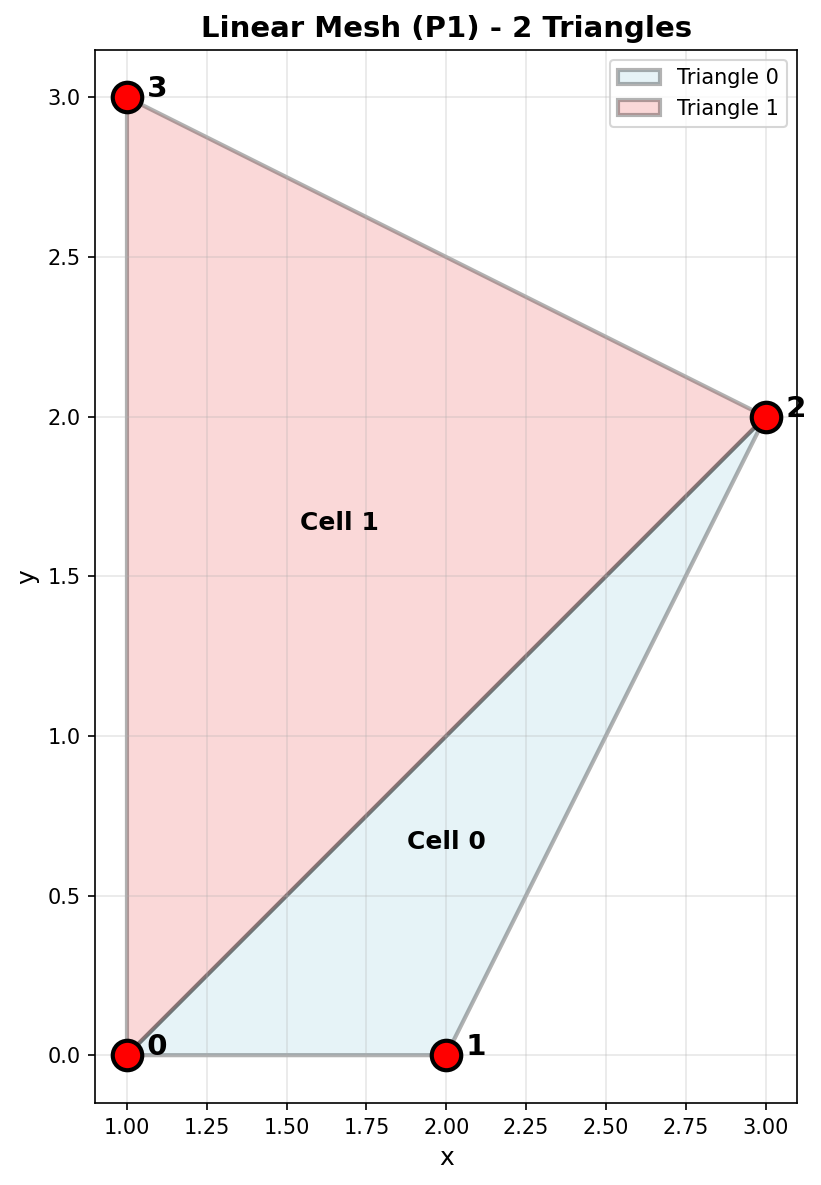

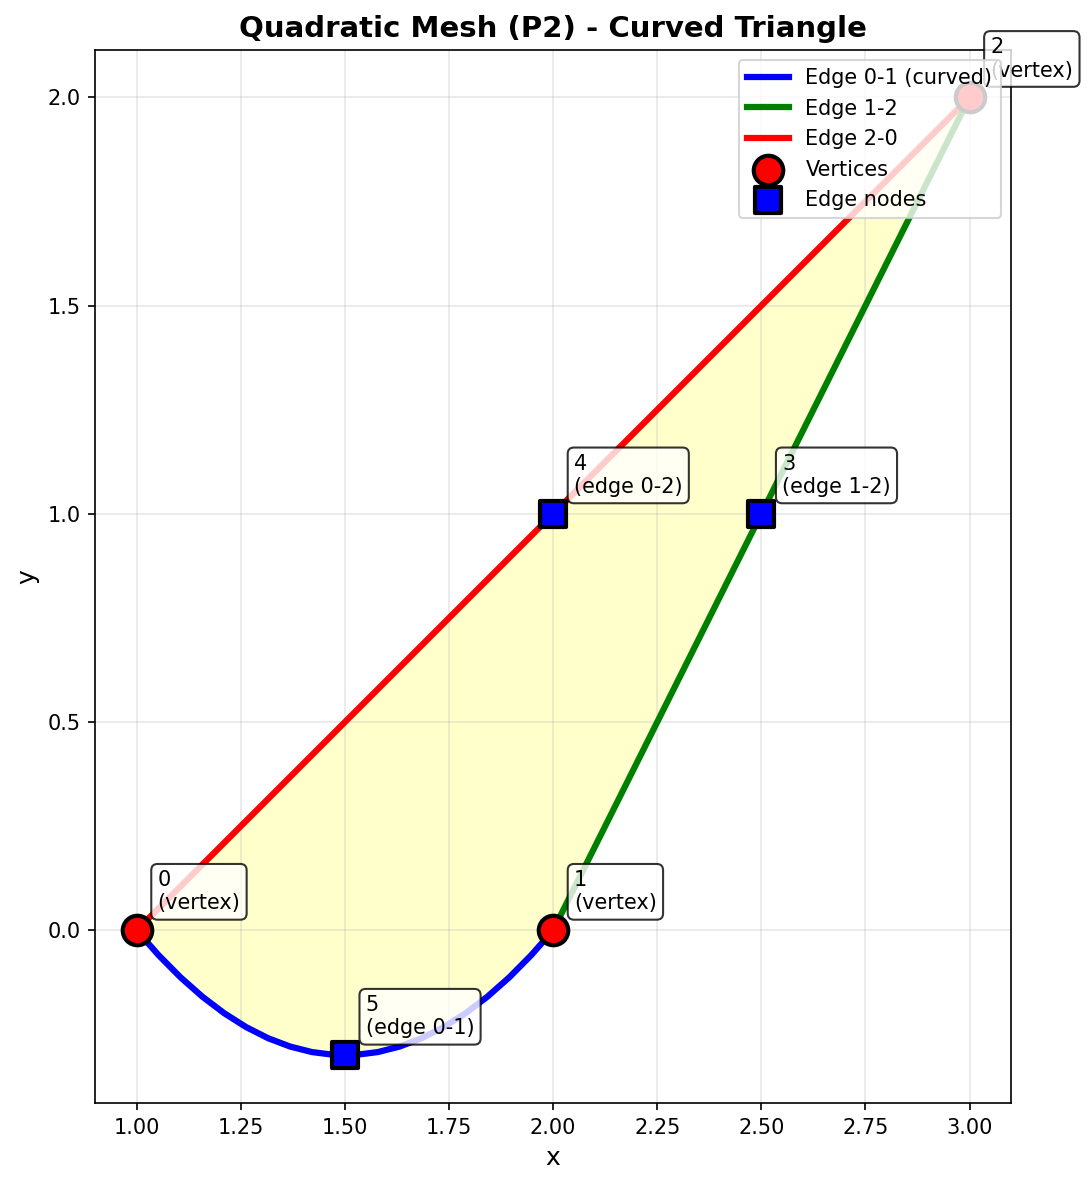

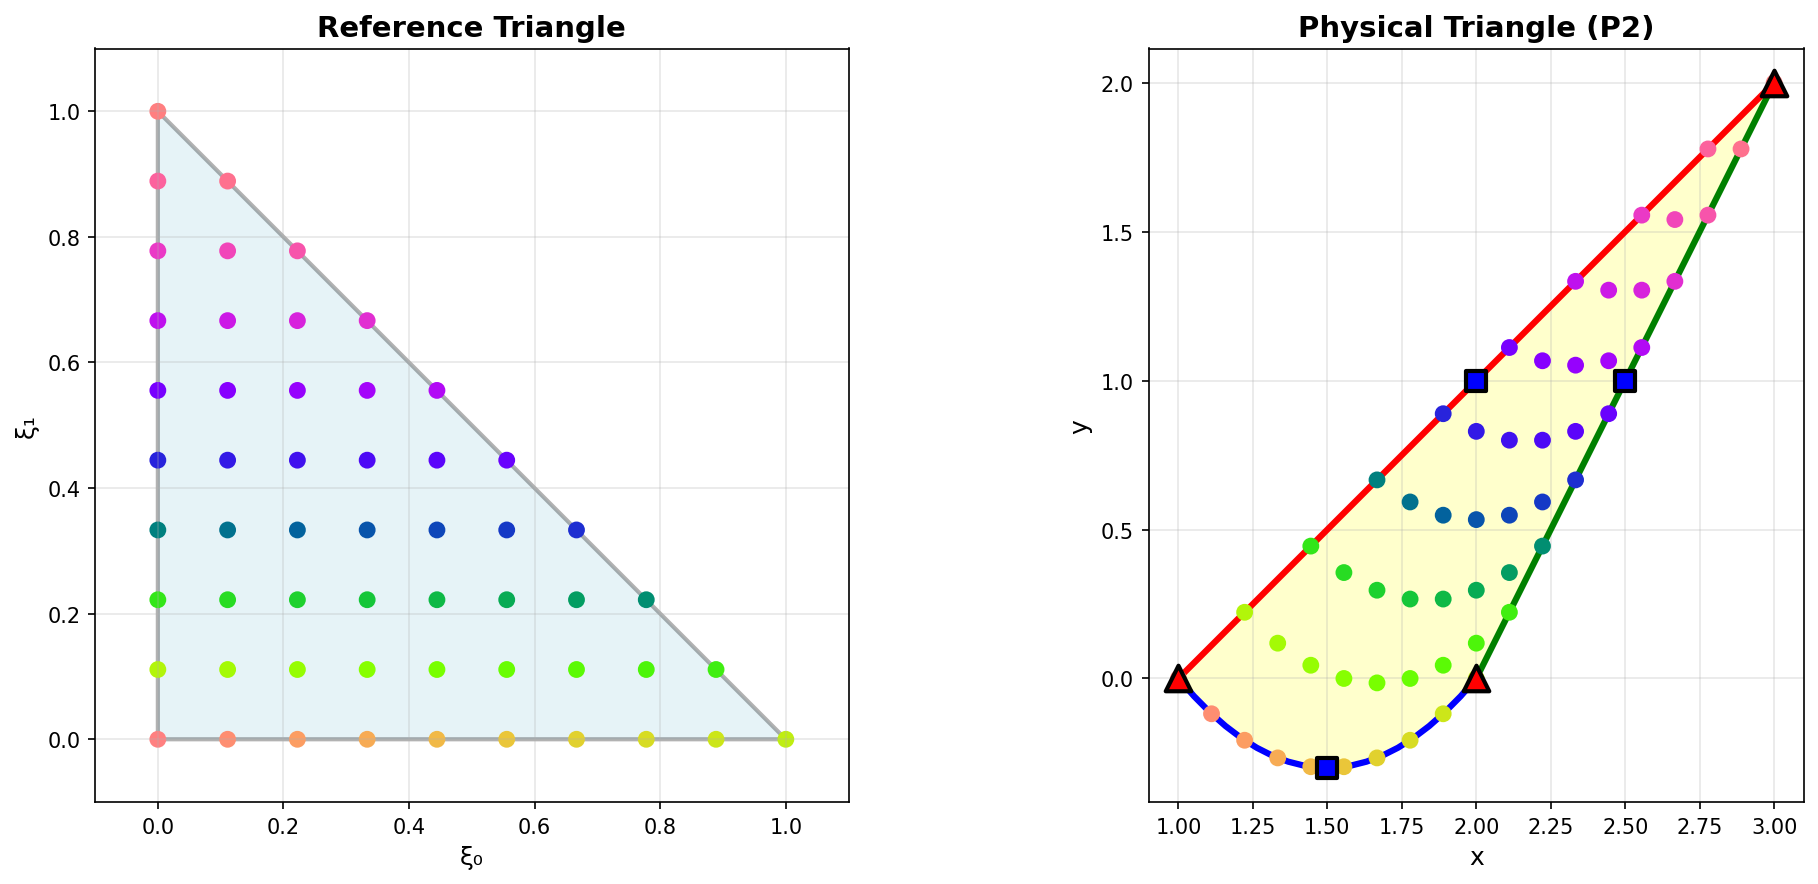

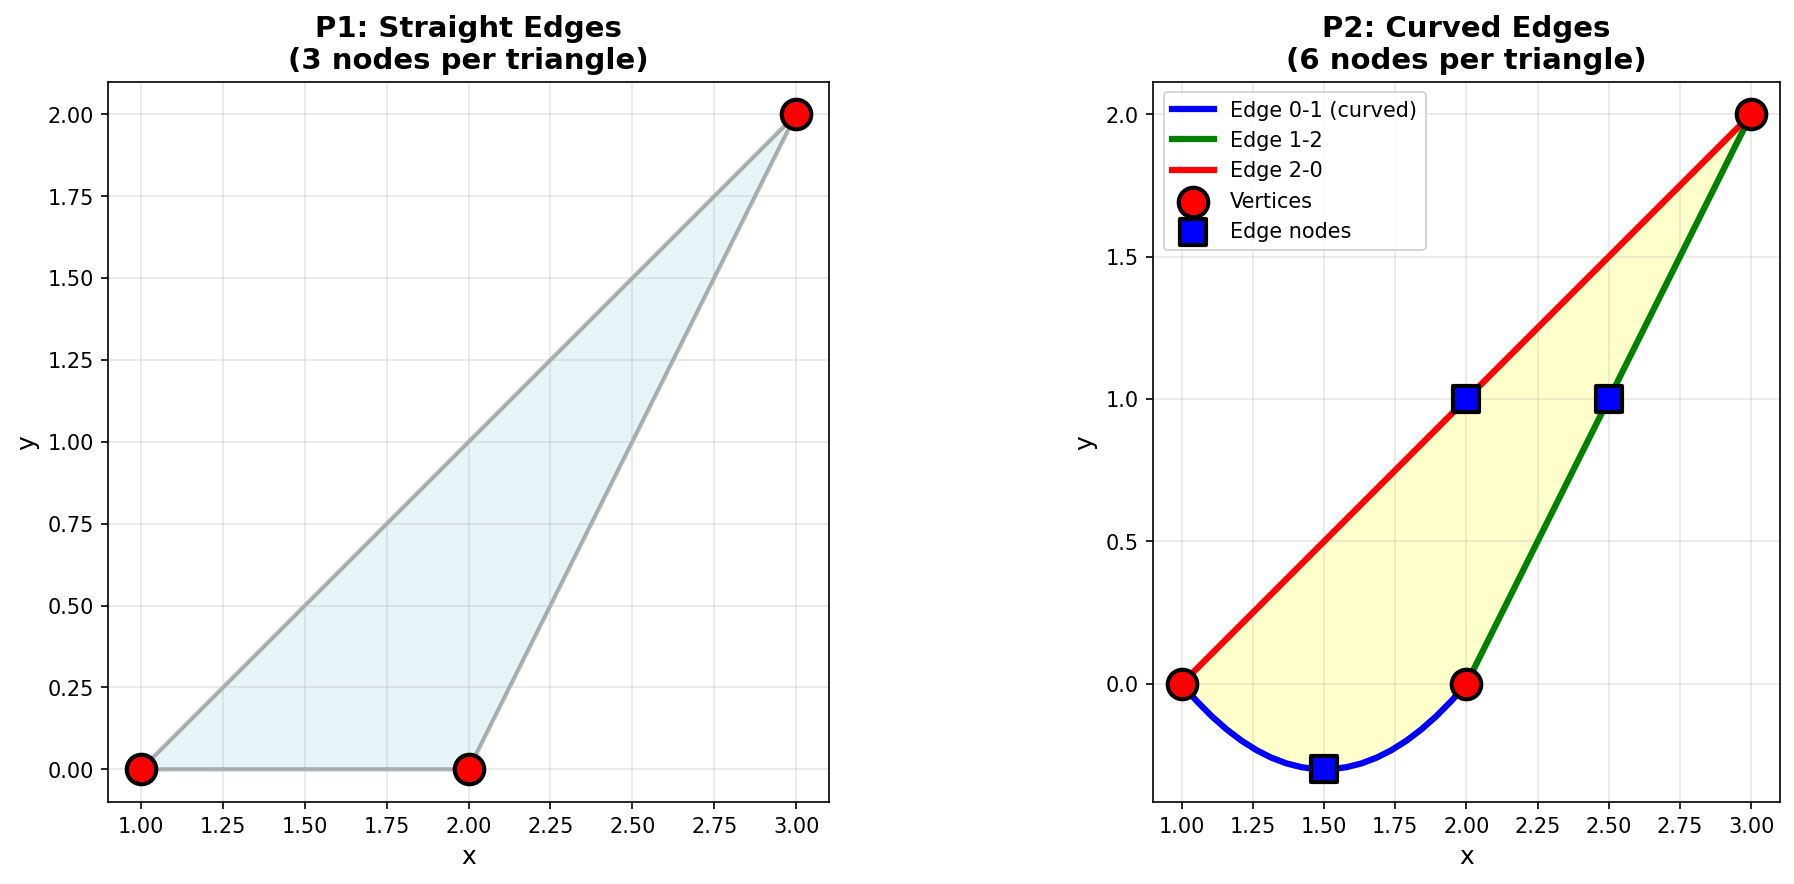

In [4]:
from IPython.display import Image, display, HTML

display(Image("mesh_p1.png"))
display(Image("mesh_p2_curved.png"))
display(Image("mapping_reference_to_physical.png"))
display(Image("p1_vs_p2_comparison.png"))